# Visualising ACTRIS data with Providentia

## Import libraries

In [1]:
%matplotlib inline

In [2]:
import sys
sys.path.append('/tljh-home/shared/providentia')

In [3]:
import providentia as prv

## Load configuration file

We are going to load hourly data for ozone mass concentration from the ACTRIS framework for the year 2018.

In [4]:
provi = prv.Providentia('actris_vre.conf')

In [5]:
provi.print_config()

[ACTRIS]
framework = actris/actris
species = ozone mass concentration
resolution = hourly
start_date = 20240101
end_date = 20250101
report_type = standard
report_summary = True
report_stations = False
report_filename = PROVIDENTIA_Report
report_title = Report
observations_data_label = Ozone Mass Concentration
dl_thredds_update = False


## Download data

Now we format and download the data from NILU Thredds server (`https://thredds.nilu.no/thredds/catalog/ebas_doi/catalog.html`) into the path defined in `settings/data_paths.json` for local machines.

In [6]:
provi.download()

Starting Providentia download...

Starting ACTRIS section download...



There are some files that were already downloaded in a previous download, do you want to overwrite them ([y]/n)?  



----------------------------------------


  - /home/avilanov/data/providentia/obs/nonghost/actris/actris/hourly/sconco3, source: https://prod-actris-md2.nilu.no/metadata/content/ozone mass concentration


    Processing station data: 100%|█████████████████████████████████████████| 94/94

    === ERRORS (7) ===
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/BK/7Q/E7/BK7Q-E7TT.nc (US1200R): Opening file: NetCDF: Access failure.
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/CP/HG/6U/CPHG-6UUG.nc (US6001R): Opening file: NetCDF: Access failure.
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/DP/4J/XX/DP4J-XXFY.nc (DK0025G): Opening file: NetCDF: Access failure.
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/K7/H9/6Y/K7H9-6YVZ.nc (US6005G): Opening file: NetCDF: Access failure.
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/P3/NZ/JR/P3NZ-JR85.nc (US6004G): Opening file: NetCDF: Access failure.
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/PY/M7/CH/PYM7-CHMW.nc (GR0002R): Opening file: NetCDF: Access failure.
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/R5/T2/BQ/R5T2-BQ47.nc (NZ0003G): Opening file: NetCDF: Access failure.
    === WARNINGS (7) ===
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/CA/9B/FE/CA9B-FEA3.nc (NZ0002R): No data availa

## Read data

It is time to explore the data, for this we need to first load it in memory.

In [7]:
provi.load()


Updating file tree /home/avilanov/software/providentia/settings/internal/ghost_filetree_1.5.json...
Updating file tree /home/avilanov/software/providentia/settings/internal/nonghost_filetree.json...
Reading data

OBSERVATIONS
 - actris/actris|sconco3
Resetting data filters to when class was initialised, loading ACTRIS subsection filters.
Filtering data


In [8]:
data = provi.data(format='xr')
data

<xarray.Dataset> Size: 5MB
Dimensions:                                                       (
                                                                   data_label: 1,
                                                                   station_actris_actris|sconco3: 80,
                                                                   time: 8784,
                                                                   month: 12)
Coordinates:
  * time                                                          (time) datetime64[ns] 70kB ...
Dimensions without coordinates: data_label, station_actris_actris|sconco3, month
Data variables: (12/29)
    data_labels                                                   (data_label) <U24 96B ...
    actris_actris|sconco3_data                                    (data_label, station_actris_actris|sconco3, time) float32 3MB ...
    actris_actris|sconco3_station_reference                       (station_actris_actris|sconco3, month) <U7 27kB ...
    actris_actris|sconco3_longitude                               (station_actris_actris|sconco3, month) float64 8kB ...
    actris_actris|sconco3_latitude                                (station_actris_actris|sconco3, month) float64 8kB ...
    actris_actris|sconco3_station_name                            (station_actris_actris|sconco3, month) <U34 131kB ...
    ...                                                            ...
    actris_actris|sconco3_contact_name                            (station_actris_actris|sconco3, month) <U75 288kB ...
    actris_actris|sconco3_contact_institution                     (station_actris_actris|sconco3, month) <U4 15kB ...
    actris_actris|sconco3_contact_email_address                   (station_actris_actris|sconco3, month) <U12 46kB ...
    actris_actris|sconco3_data_licence                            (station_actris_actris|sconco3, month) <U3 12kB ...
    actris_actris|sconco3_doi                                     (station_actris_actris|sconco3, month) <U4 15kB ...
    actris_actris|sconco3_actris_national_facility                (station_actris_actris|sconco3, month) <U5 19kB ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

The variable data is stored in `actris_actris|sconco3_data` by label (in this case only observations), station and time.

In [9]:
data['actris_actris|sconco3_data']

<xarray.DataArray 'actris_actris|sconco3_data' (data_label: 1,
                                                station_actris_actris|sconco3: 80,
                                                time: 8784)> Size: 3MB
array([[[27.256, 24.802, 21.649, ..., 25.161, 25.081, 23.784],
        [   nan,    nan,    nan, ..., 30.8  , 28.2  , 27.5  ],
        [53.4  , 56.3  , 55.4  , ..., 66.9  , 66.2  , 67.9  ],
        ...,
        [63.552, 72.551, 60.04 , ..., 70.396, 69.677, 69.318],
        [42.281, 41.004, 45.055, ...,    nan,    nan,    nan],
        [37.31 , 38.51 , 39.31 , ...,    nan,    nan,    nan]]],
      shape=(1, 80, 8784), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23:00:00
Dimensions without coordinates: data_label, station_actris_actris|sconco3
Attributes: (12/26)
    standard_name:                            ozone
    long_name:                                ozone
    units:                                    nmol mol-1
    description:                              Measured value of surface ozone...
    resolution:                               hourly
    resampling_resolution:                    None
    ...                                       ...
    spatial_colocation_station_reference:     True
    spatial_colocation_station_name:          True
    spatial_colocation_longitude_latitude:    True
    spatial_colocation_measurement_altitude:  True
    spatial_colocation_validation:            True
    spatial_colocation_validation_tolerance:  10000.0

While the station information is stored in different variables by month, such as `actris_actris|sconco3_station_reference`, `actris_actris|sconco3_station_name`, `actris_actris|sconco3_latitude` and `actris_actris|sconco3_longitude`.

In [10]:
data['actris_actris|sconco3_station_reference']

<xarray.DataArray 'actris_actris|sconco3_station_reference' (
                                                             station_actris_actris|sconco3: 80,
                                                             month: 12)> Size: 27kB
array([['AR0002G', 'AR0002G', 'AR0002G', 'AR0002G', 'AR0002G', 'AR0002G',
        'AR0002G', 'AR0002G', 'AR0002G', 'AR0002G', 'AR0002G', 'AR0002G'],
       ['AT0002R', 'AT0002R', 'AT0002R', 'AT0002R', 'AT0002R', 'AT0002R',
        'AT0002R', 'AT0002R', 'AT0002R', 'AT0002R', 'AT0002R', 'AT0002R'],
       ['AT0005R', 'AT0005R', 'AT0005R', 'AT0005R', 'AT0005R', 'AT0005R',
        'AT0005R', 'AT0005R', 'AT0005R', 'AT0005R', 'AT0005R', 'AT0005R'],
       ['AT0030R', 'AT0030R', 'AT0030R', 'AT0030R', 'AT0030R', 'AT0030R',
        'AT0030R', 'AT0030R', 'AT0030R', 'AT0030R', 'AT0030R', 'AT0030R'],
       ['AT0032R', 'AT0032R', 'AT0032R', 'AT0032R', 'AT0032R', 'AT0032R',
        'AT0032R', 'AT0032R', 'AT0032R', 'AT0032R', 'AT0032R', 'AT0032R'],
       ['AT0034G', 'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G',
        'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G'],
       ['AT0040R', 'AT0040R', 'AT0040R', 'AT0040R', 'AT0040R', 'AT0040R',
        'AT0040R', 'AT0040R', 'AT0040R', 'AT0040R', 'AT0040R', 'AT0040R'],
       ['AT0041R', 'AT0041R', 'AT0041R', 'AT0041R', 'AT0041R', 'AT0041R',
        'AT0041R', 'AT0041R', 'AT0041R', 'AT0041R', 'AT0041R', 'AT0041R'],
       ['AT0042R', 'AT0042R', 'AT0042R', 'AT0042R', 'AT0042R', 'AT0042R',
        'AT0042R', 'AT0042R', 'AT0042R', 'AT0042R', 'AT0042R', 'AT0042R'],
       ['AT0043R', 'AT0043R', 'AT0043R', 'AT0043R', 'AT0043R', 'AT0043R',
        'AT0043R', 'AT0043R', 'AT0043R', 'AT0043R', 'AT0043R', 'AT0043R'],
...
        'SI0008R', 'SI0008R', 'SI0008R', 'SI0008R', 'SI0008R', 'SI0008R'],
       ['SI0031R', 'SI0031R', 'SI0031R', 'SI0031R', 'SI0031R', 'SI0031R',
        'SI0031R', 'SI0031R', 'SI0031R', 'SI0031R', 'SI0031R', 'SI0031R'],
       ['SI0032R', 'SI0032R', 'SI0032R', 'SI0032R', 'SI0032R', 'SI0032R',
        'SI0032R', 'SI0032R', 'SI0032R', 'SI0032R', 'SI0032R', 'SI0032R'],
       ['SK0002R', 'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R',
        'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R'],
       ['SK0006R', 'SK0006R', 'SK0006R', 'SK0006R', 'SK0006R', 'SK0006R',
        'SK0006R', 'SK0006R', 'SK0006R', 'SK0006R', 'SK0006R', 'SK0006R'],
       ['SK0007R', 'SK0007R', 'nan', 'nan', 'nan', 'nan', 'nan',
        'SK0007R', 'SK0007R', 'SK0007R', 'SK0007R', 'SK0007R'],
       ['US0008R', 'US0008R', 'US0008R', 'US0008R', 'US0008R', 'US0008R',
        'US0008R', 'US0008R', 'US0008R', 'US0008R', 'US0008R', 'US0008R'],
       ['US0901R', 'US0901R', 'US0901R', 'US0901R', 'US0901R', 'US0901R',
        'US0901R', 'US0901R', 'US0901R', 'US0901R', 'US0901R', 'US0901R'],
       ['VN0001R', 'VN0001R', 'VN0001R', 'VN0001R', 'VN0001R', 'VN0001R',
        'VN0001R', 'VN0001R', 'VN0001R', 'VN0001R', 'VN0001R', 'VN0001R'],
       ['ZA0001G', 'ZA0001G', 'ZA0001G', 'ZA0001G', 'ZA0001G', 'ZA0001G',
        'ZA0001G', 'ZA0001G', 'ZA0001G', 'ZA0001G', 'ZA0001G', 'ZA0001G']],
      dtype='<U7')
Dimensions without coordinates: station_actris_actris|sconco3, month
Attributes:
    standard_name:  station reference
    long_name:      station reference identifier
    units:          unitless
    description:    reference ID for station.

In [11]:
data['actris_actris|sconco3_station_name']

<xarray.DataArray 'actris_actris|sconco3_station_name' (
                                                        station_actris_actris|sconco3: 80,
                                                        month: 12)> Size: 131kB
array([['Ushuaia', 'Ushuaia', 'Ushuaia', 'Ushuaia', 'Ushuaia', 'Ushuaia',
        'Ushuaia', 'Ushuaia', 'Ushuaia', 'Ushuaia', 'Ushuaia', 'Ushuaia'],
       ['Illmitz', 'Illmitz', 'Illmitz', 'Illmitz', 'Illmitz', 'Illmitz',
        'Illmitz', 'Illmitz', 'Illmitz', 'Illmitz', 'Illmitz', 'Illmitz'],
       ['Vorhegg', 'Vorhegg', 'Vorhegg', 'Vorhegg', 'Vorhegg', 'Vorhegg',
        'Vorhegg', 'Vorhegg', 'Vorhegg', 'Vorhegg', 'Vorhegg', 'Vorhegg'],
       ['Pillersdorf bei Retz', 'Pillersdorf bei Retz',
        'Pillersdorf bei Retz', 'Pillersdorf bei Retz',
        'Pillersdorf bei Retz', 'Pillersdorf bei Retz',
        'Pillersdorf bei Retz', 'Pillersdorf bei Retz',
        'Pillersdorf bei Retz', 'Pillersdorf bei Retz',
        'Pillersdorf bei Retz', 'Pillersdorf bei Retz'],
       ['Sulzberg', 'Sulzberg', 'Sulzberg', 'Sulzberg', 'Sulzberg',
        'Sulzberg', 'Sulzberg', 'Sulzberg', 'Sulzberg', 'Sulzberg',
        'Sulzberg', 'Sulzberg'],
       ['Sonnblick', 'Sonnblick', 'Sonnblick', 'Sonnblick', 'Sonnblick',
        'Sonnblick', 'Sonnblick', 'Sonnblick', 'Sonnblick', 'Sonnblick',
        'Sonnblick', 'Sonnblick'],
       ['Masenberg', 'Masenberg', 'Masenberg', 'Masenberg', 'Masenberg',
        'Masenberg', 'Masenberg', 'Masenberg', 'Masenberg', 'Masenberg',
...
       ['Chopok', 'Chopok', 'Chopok', 'Chopok', 'Chopok', 'Chopok',
        'Chopok', 'Chopok', 'Chopok', 'Chopok', 'Chopok', 'Chopok'],
       ['Starina', 'Starina', 'Starina', 'Starina', 'Starina', 'Starina',
        'Starina', 'Starina', 'Starina', 'Starina', 'Starina', 'Starina'],
       ['Topolniky', 'Topolniky', 'nan', 'nan', 'nan', 'nan', 'nan',
        'Topolniky', 'Topolniky', 'Topolniky', 'Topolniky', 'Topolniky'],
       ['Barrow', 'Barrow', 'Barrow', 'Barrow', 'Barrow', 'Barrow',
        'Barrow', 'Barrow', 'Barrow', 'Barrow', 'Barrow', 'Barrow'],
       ['Boulder Table Mountain', 'Boulder Table Mountain',
        'Boulder Table Mountain', 'Boulder Table Mountain',
        'Boulder Table Mountain', 'Boulder Table Mountain',
        'Boulder Table Mountain', 'Boulder Table Mountain',
        'Boulder Table Mountain', 'Boulder Table Mountain',
        'Boulder Table Mountain', 'Boulder Table Mountain'],
       ['Pha Din', 'Pha Din', 'Pha Din', 'Pha Din', 'Pha Din', 'Pha Din',
        'Pha Din', 'Pha Din', 'Pha Din', 'Pha Din', 'Pha Din', 'Pha Din'],
       ['Cape Point', 'Cape Point', 'Cape Point', 'Cape Point',
        'Cape Point', 'Cape Point', 'Cape Point', 'Cape Point',
        'Cape Point', 'Cape Point', 'Cape Point', 'Cape Point']],
      dtype='<U34')
Dimensions without coordinates: station_actris_actris|sconco3, month
Attributes:
    standard_name:  station name
    long_name:      station name
    units:          unitless
    description:    Name of station where the measurement was conducted.

In [12]:
data['actris_actris|sconco3_latitude']

<xarray.DataArray 'actris_actris|sconco3_latitude' (
                                                    station_actris_actris|sconco3: 80,
                                                    month: 12)> Size: 8kB
array([[-54.84846497, -54.84846497, -54.84846497, -54.84846497,
        -54.84846497, -54.84846497, -54.84846497, -54.84846497,
        -54.84846497, -54.84846497, -54.84846497, -54.84846497],
       [ 47.76666   ,  47.76666   ,  47.76666   ,  47.76666   ,
         47.76666   ,  47.76666   ,  47.76666   ,  47.76666   ,
         47.76666   ,  47.76666   ,  47.76666   ,  47.76666   ],
       [ 46.677778  ,  46.677778  ,  46.677778  ,  46.677778  ,
         46.677778  ,  46.677778  ,  46.677778  ,  46.677778  ,
         46.677778  ,  46.677778  ,  46.677778  ,  46.677778  ],
       [ 48.721111  ,  48.721111  ,  48.721111  ,  48.721111  ,
         48.721111  ,  48.721111  ,  48.721111  ,  48.721111  ,
         48.721111  ,  48.721111  ,  48.721111  ,  48.721111  ],
       [ 47.529167  ,  47.529167  ,  47.529167  ,  47.529167  ,
         47.529167  ,  47.529167  ,  47.529167  ,  47.529167  ,
         47.529167  ,  47.529167  ,  47.529167  ,  47.529167  ],
       [ 47.05407   ,  47.05407   ,  47.05407   ,  47.05407   ,
         47.05407   ,  47.05407   ,  47.05407   ,  47.05407   ,
         47.05407   ,  47.05407   ,  47.05407   ,  47.05407   ],
       [ 47.348056  ,  47.348056  ,  47.348056  ,  47.348056  ,
         47.348056  ,  47.348056  ,  47.348056  ,  47.348056  ,
...
         48.933333  ,  48.933333  ,  48.933333  ,  48.933333  ,
         48.933333  ,  48.933333  ,  48.933333  ,  48.933333  ],
       [ 49.05      ,  49.05      ,  49.05      ,  49.05      ,
         49.05      ,  49.05      ,  49.05      ,  49.05      ,
         49.05      ,  49.05      ,  49.05      ,  49.05      ],
       [ 47.96      ,  47.96      ,          nan,          nan,
                 nan,          nan,          nan,  47.96      ,
         47.96      ,  47.96      ,  47.96      ,  47.96      ],
       [ 71.32301331,  71.32301331,  71.32301331,  71.32301331,
         71.32301331,  71.32301331,  71.32301331,  71.32301331,
         71.32301331,  71.32301331,  71.32301331,  71.32301331],
       [ 40.12498   ,  40.12498   ,  40.12498   ,  40.12498   ,
         40.12498   ,  40.12498   ,  40.12498   ,  40.12498   ,
         40.12498   ,  40.12498   ,  40.12498   ,  40.12498   ],
       [ 21.5731    ,  21.5731    ,  21.5731    ,  21.5731    ,
         21.5731    ,  21.5731    ,  21.5731    ,  21.5731    ,
         21.5731    ,  21.5731    ,  21.5731    ,  21.5731    ],
       [-34.35348   , -34.35348   , -34.35348   , -34.35348   ,
        -34.35348   , -34.35348   , -34.35348   , -34.35348   ,
        -34.35348   , -34.35348   , -34.35348   , -34.35348   ]])
Dimensions without coordinates: station_actris_actris|sconco3, month
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          decimal degrees North
    description:    Geodetic latitude of measuring instrument, in decimal deg...
    axis:           Y

In [13]:
data['actris_actris|sconco3_longitude']

<xarray.DataArray 'actris_actris|sconco3_longitude' (
                                                     station_actris_actris|sconco3: 80,
                                                     month: 12)> Size: 8kB
array([[ -68.31069183,  -68.31069183,  -68.31069183,  -68.31069183,
         -68.31069183,  -68.31069183,  -68.31069183,  -68.31069183,
         -68.31069183,  -68.31069183,  -68.31069183,  -68.31069183],
       [  16.76666   ,   16.76666   ,   16.76666   ,   16.76666   ,
          16.76666   ,   16.76666   ,   16.76666   ,   16.76666   ,
          16.76666   ,   16.76666   ,   16.76666   ,   16.76666   ],
       [  12.972222  ,   12.972222  ,   12.972222  ,   12.972222  ,
          12.972222  ,   12.972222  ,   12.972222  ,   12.972222  ,
          12.972222  ,   12.972222  ,   12.972222  ,   12.972222  ],
       [  15.942222  ,   15.942222  ,   15.942222  ,   15.942222  ,
          15.942222  ,   15.942222  ,   15.942222  ,   15.942222  ,
          15.942222  ,   15.942222  ,   15.942222  ,   15.942222  ],
       [   9.926667  ,    9.926667  ,    9.926667  ,    9.926667  ,
           9.926667  ,    9.926667  ,    9.926667  ,    9.926667  ,
           9.926667  ,    9.926667  ,    9.926667  ,    9.926667  ],
       [  12.95794   ,   12.95794   ,   12.95794   ,   12.95794   ,
          12.95794   ,   12.95794   ,   12.95794   ,   12.95794   ,
          12.95794   ,   12.95794   ,   12.95794   ,   12.95794   ],
       [  15.882222  ,   15.882222  ,   15.882222  ,   15.882222  ,
          15.882222  ,   15.882222  ,   15.882222  ,   15.882222  ,
...
          19.583333  ,   19.583333  ,   19.583333  ,   19.583333  ,
          19.583333  ,   19.583333  ,   19.583333  ,   19.583333  ],
       [  22.266667  ,   22.266667  ,   22.266667  ,   22.266667  ,
          22.266667  ,   22.266667  ,   22.266667  ,   22.266667  ,
          22.266667  ,   22.266667  ,   22.266667  ,   22.266667  ],
       [  17.860556  ,   17.860556  ,           nan,           nan,
                  nan,           nan,           nan,   17.860556  ,
          17.860556  ,   17.860556  ,   17.860556  ,   17.860556  ],
       [-156.6114655 , -156.6114655 , -156.6114655 , -156.6114655 ,
        -156.6114655 , -156.6114655 , -156.6114655 , -156.6114655 ,
        -156.6114655 , -156.6114655 , -156.6114655 , -156.6114655 ],
       [-105.2368    , -105.2368    , -105.2368    , -105.2368    ,
        -105.2368    , -105.2368    , -105.2368    , -105.2368    ,
        -105.2368    , -105.2368    , -105.2368    , -105.2368    ],
       [ 103.5157    ,  103.5157    ,  103.5157    ,  103.5157    ,
         103.5157    ,  103.5157    ,  103.5157    ,  103.5157    ,
         103.5157    ,  103.5157    ,  103.5157    ,  103.5157    ],
       [  18.48968   ,   18.48968   ,   18.48968   ,   18.48968   ,
          18.48968   ,   18.48968   ,   18.48968   ,   18.48968   ,
          18.48968   ,   18.48968   ,   18.48968   ,   18.48968   ]])
Dimensions without coordinates: station_actris_actris|sconco3, month
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          decimal degrees East
    description:    Geodetic longitude of measuring instrument, in decimal de...
    axis:           X

## Save data

Data can be saved as netCDF or Numpy.

### Save to netCDF

In [14]:
provi.save(format='nc')

Data saved to /home/avilanov/software/providentia/saved_data/PRV_20260611_1716.nc


### Save to Numpy

In [15]:
provi.save(format='np')

Data saved to /home/avilanov/software/providentia/saved_data/PRV_20260611_1716.npz


## Plot

The statistics that can be plotted are: `Mean`, `Median`, `StdDev`, `Var`, `Min`, `Max`, `NData`, `Data%`, `NStations`, `Exceedances`, `p1`, `p5`, `p10`, `p25`, `p75` , `p90`, `p95`, `p99` and `MDA8`.

### Maps

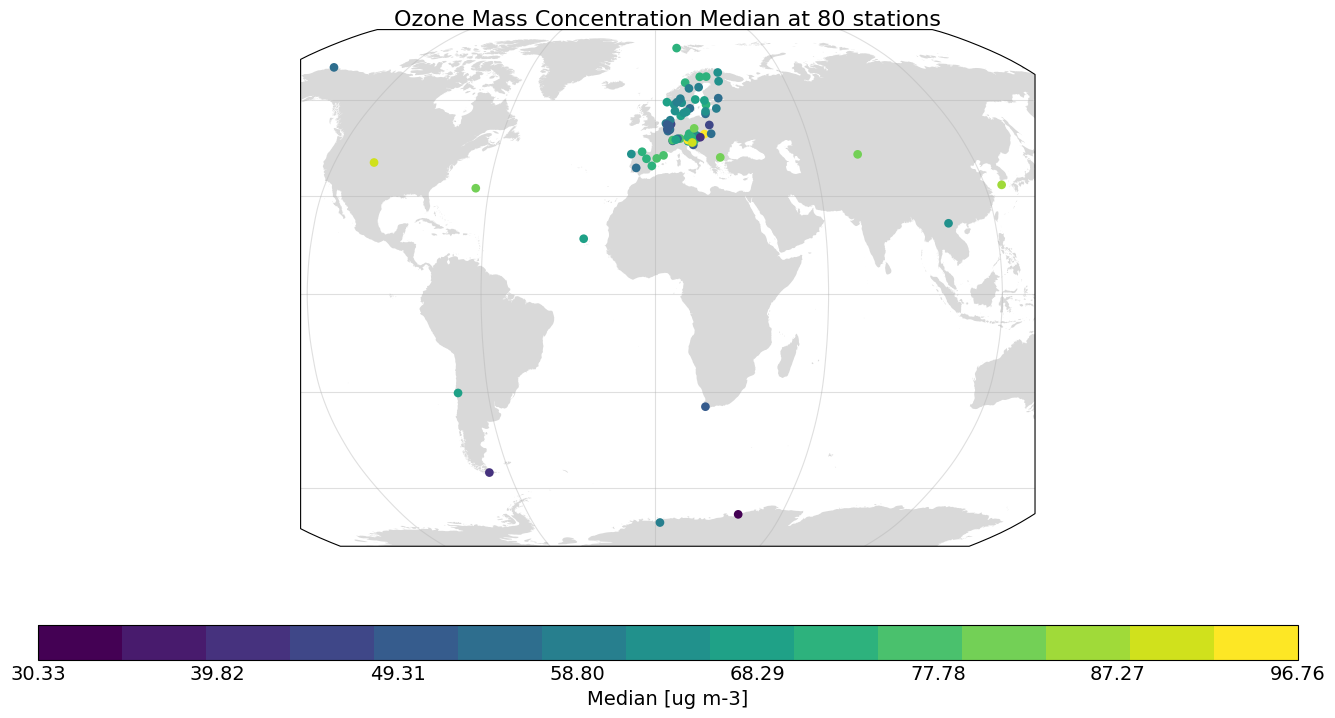

In [16]:
provi.plot('map-Median')

### Timeseries

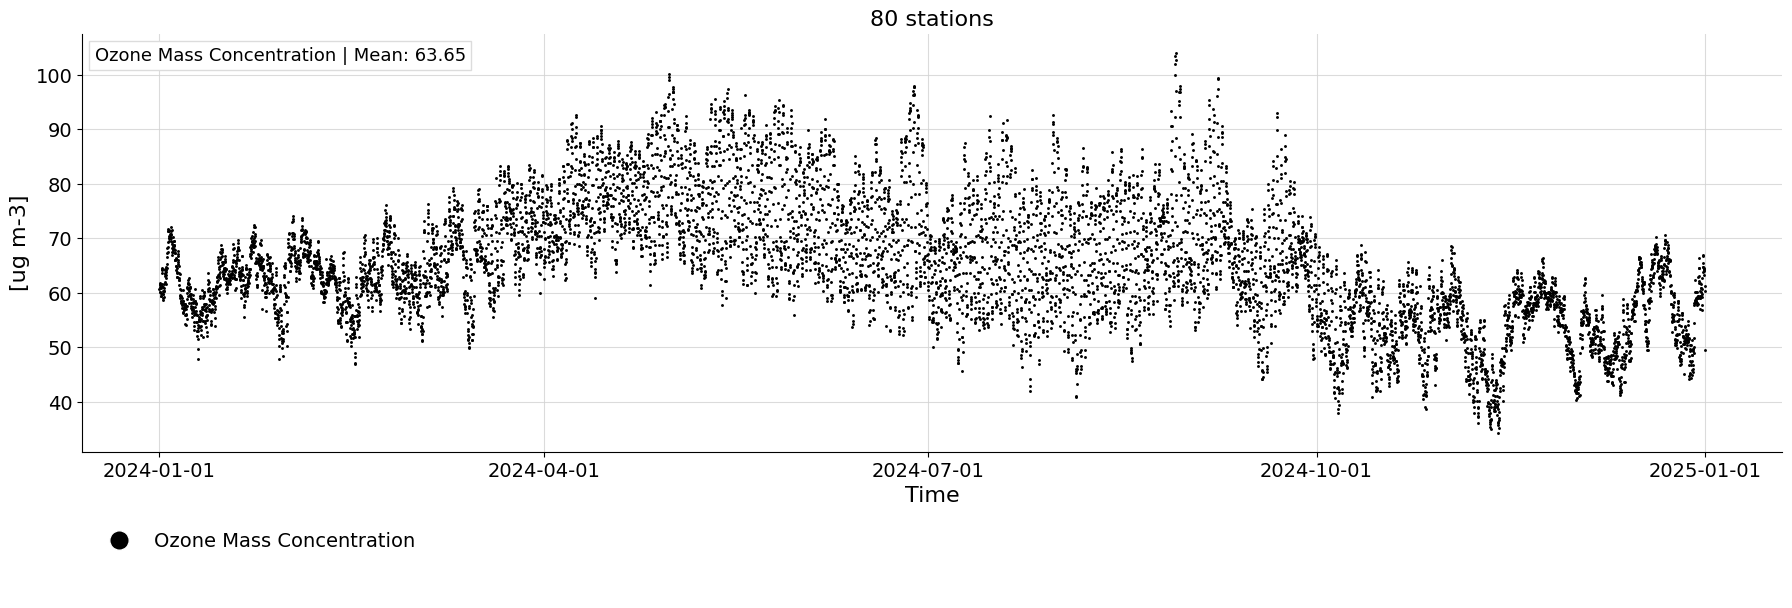

In [17]:
provi.plot('timeseries', annotate=True)

### Periodic plots

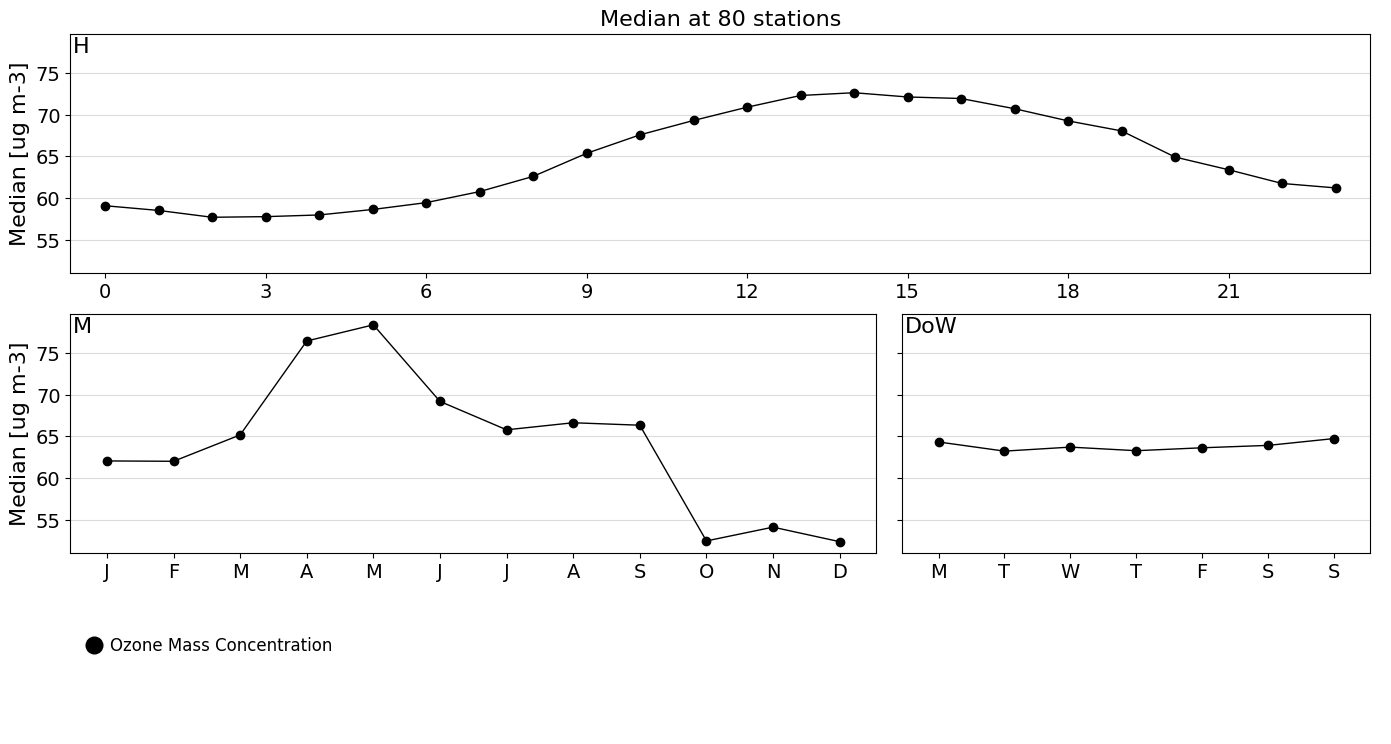

In [18]:
provi.plot('periodic-Median')

### Periodic violin plots

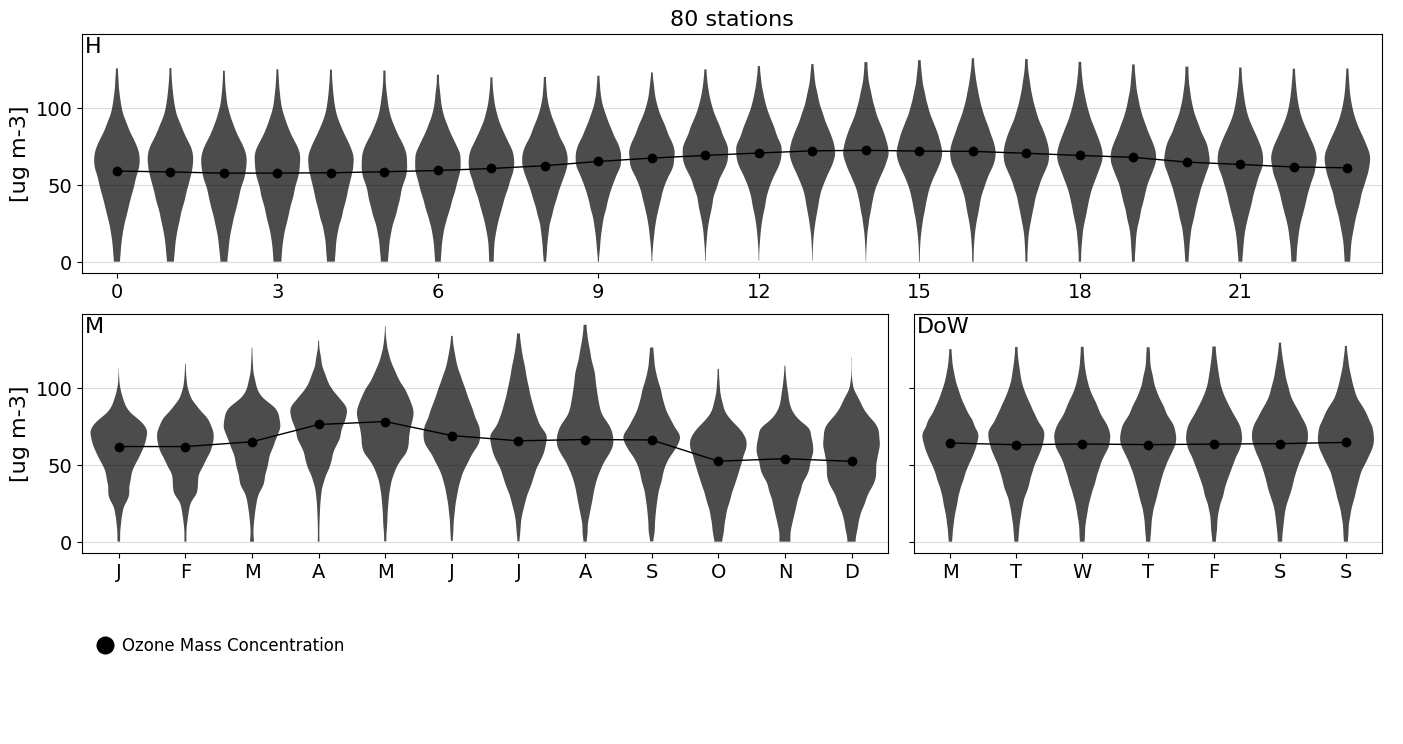

In [19]:
provi.plot('periodic-violin')

### Distribution plots

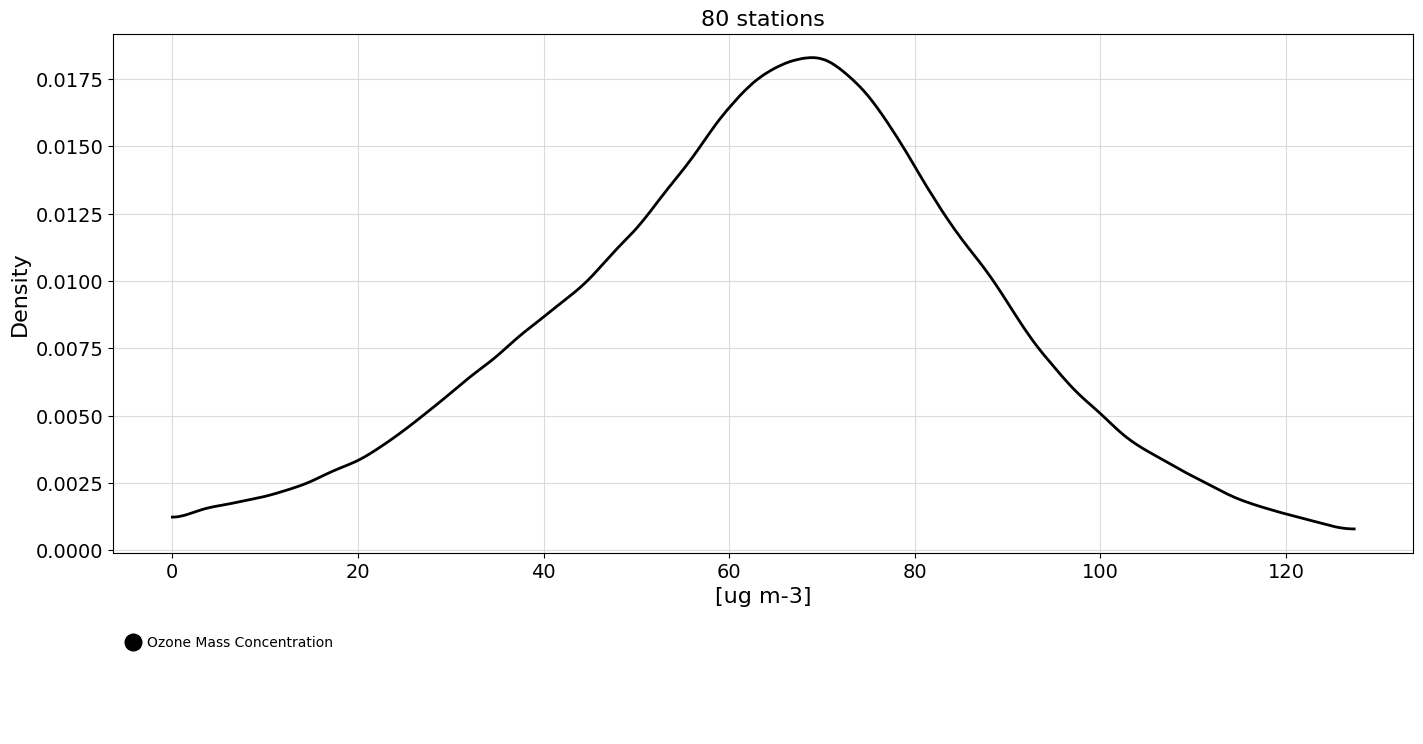

In [20]:
provi.plot('distribution')

### Boxplot

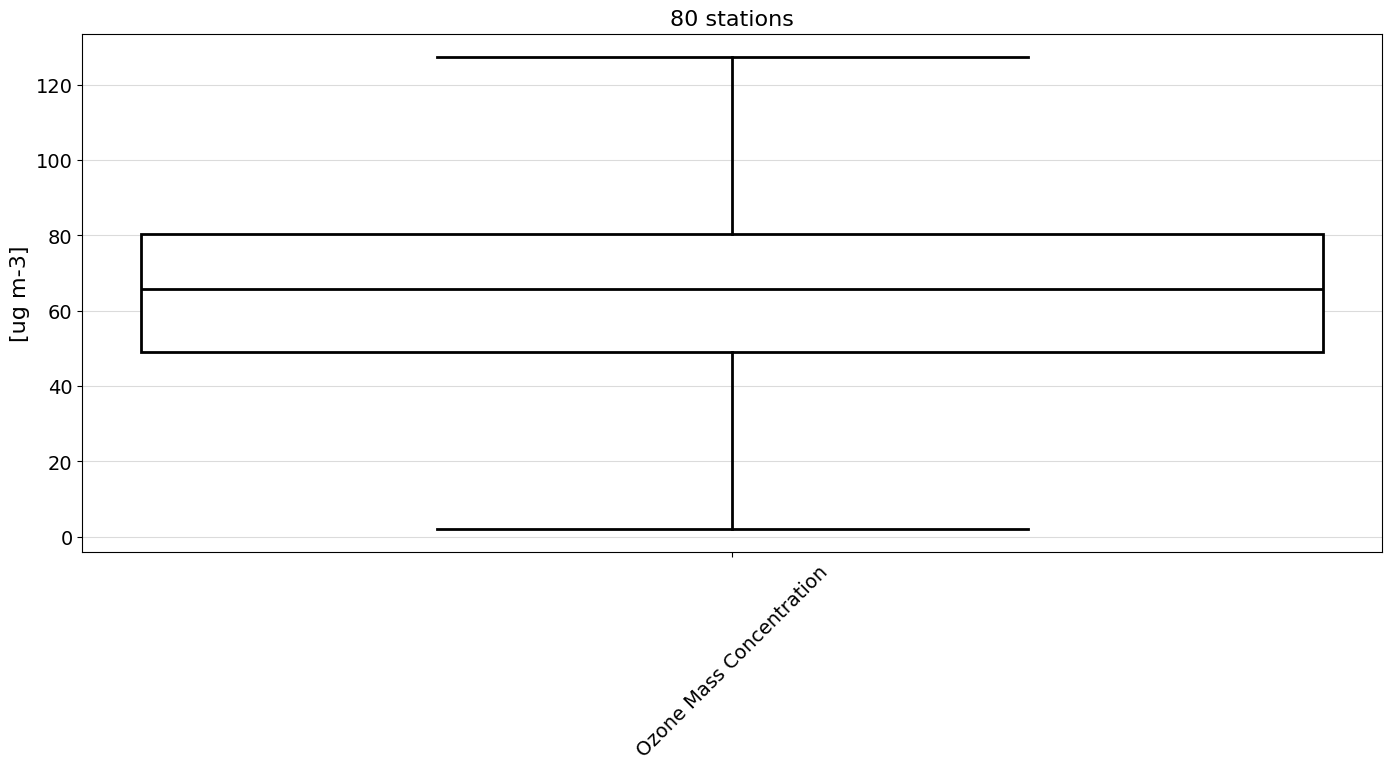

In [21]:
provi.plot('boxplot')

## Filter data

### By country

We can use the metadata to easily filter by country. In this case, we will select all stations in Norway and Spain.

In [22]:
# filter data by country metadata 
provi.reset()
provi.filter('country', keep=['Norway','Spain'])
stations_data = provi.data(format='xr')
stations_data

Resetting all data filters.
Filtering data
Filtering data


<xarray.Dataset> Size: 906kB
Dimensions:                                                       (
                                                                   data_label: 1,
                                                                   station_actris_actris|sconco3: 16,
                                                                   time: 8784,
                                                                   month: 12)
Coordinates:
  * time                                                          (time) datetime64[ns] 70kB ...
Dimensions without coordinates: data_label, station_actris_actris|sconco3, month
Data variables: (12/29)
    data_labels                                                   (data_label) <U24 96B ...
    actris_actris|sconco3_data                                    (data_label, station_actris_actris|sconco3, time) float32 562kB ...
    actris_actris|sconco3_station_reference                       (station_actris_actris|sconco3, month) <U7 5kB ...
    actris_actris|sconco3_longitude                               (station_actris_actris|sconco3, month) float64 2kB ...
    actris_actris|sconco3_latitude                                (station_actris_actris|sconco3, month) float64 2kB ...
    actris_actris|sconco3_station_name                            (station_actris_actris|sconco3, month) <U30 23kB ...
    ...                                                            ...
    actris_actris|sconco3_contact_name                            (station_actris_actris|sconco3, month) <U63 48kB ...
    actris_actris|sconco3_contact_institution                     (station_actris_actris|sconco3, month) <U4 3kB ...
    actris_actris|sconco3_contact_email_address                   (station_actris_actris|sconco3, month) <U12 9kB ...
    actris_actris|sconco3_data_licence                            (station_actris_actris|sconco3, month) <U3 2kB ...
    actris_actris|sconco3_doi                                     (station_actris_actris|sconco3, month) <U4 3kB ...
    actris_actris|sconco3_actris_national_facility                (station_actris_actris|sconco3, month) <U5 4kB ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

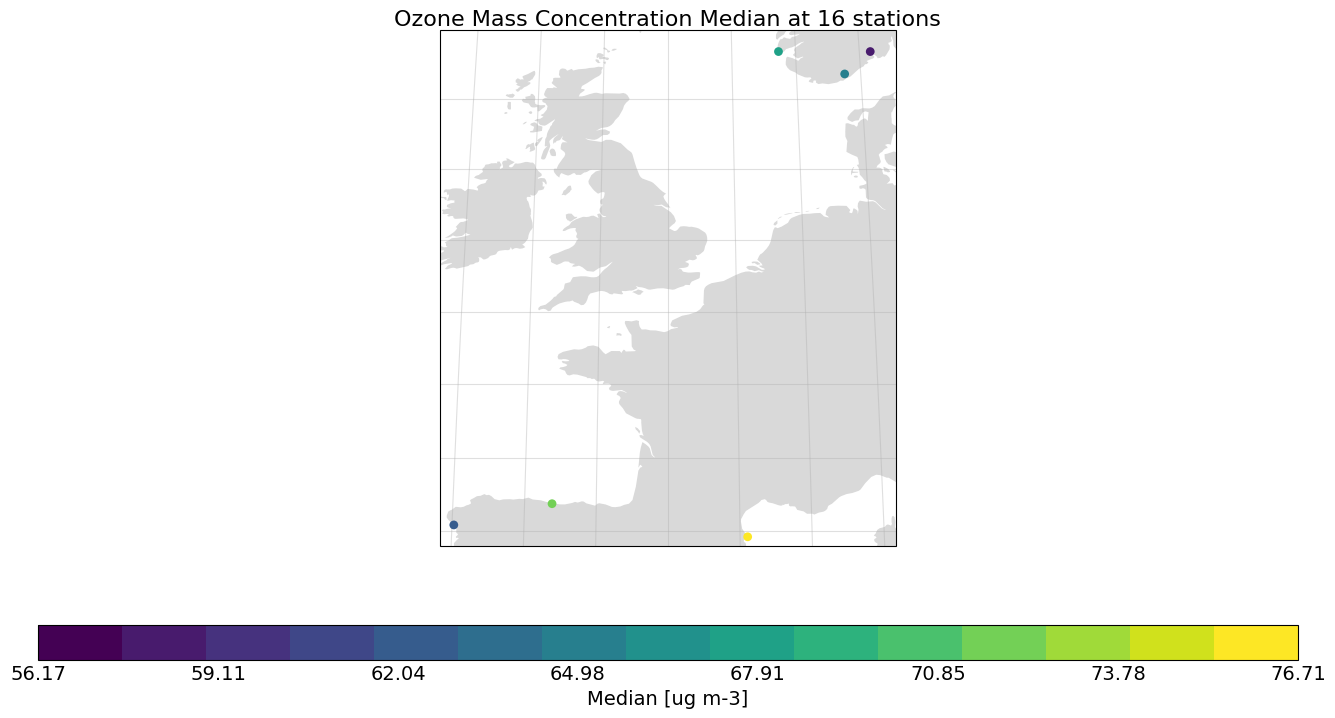

In [23]:
provi.plot('map-Median', map_extent=[-10, 10, 42, 60])

### By altitude

Now we reset the filters, and filter by altitudes of at least 2000m.

In [24]:
# filter data by station altitude
provi.reset()
provi.filter('altitude', lower=2000)
stations_data = provi.data(format='xr')
stations_data

Resetting all data filters.
Filtering data
Filtering data


<xarray.Dataset> Size: 221kB
Dimensions:                                                       (
                                                                   data_label: 1,
                                                                   station_actris_actris|sconco3: 3,
                                                                   time: 8784,
                                                                   month: 12)
Coordinates:
  * time                                                          (time) datetime64[ns] 70kB ...
Dimensions without coordinates: data_label, station_actris_actris|sconco3, month
Data variables: (12/29)
    data_labels                                                   (data_label) <U24 96B ...
    actris_actris|sconco3_data                                    (data_label, station_actris_actris|sconco3, time) float32 105kB ...
    actris_actris|sconco3_station_reference                       (station_actris_actris|sconco3, month) <U7 1kB ...
    actris_actris|sconco3_longitude                               (station_actris_actris|sconco3, month) float64 288B ...
    actris_actris|sconco3_latitude                                (station_actris_actris|sconco3, month) float64 288B ...
    actris_actris|sconco3_station_name                            (station_actris_actris|sconco3, month) <U9 1kB ...
    ...                                                            ...
    actris_actris|sconco3_contact_name                            (station_actris_actris|sconco3, month) <U56 8kB ...
    actris_actris|sconco3_contact_institution                     (station_actris_actris|sconco3, month) <U4 576B ...
    actris_actris|sconco3_contact_email_address                   (station_actris_actris|sconco3, month) <U12 2kB ...
    actris_actris|sconco3_data_licence                            (station_actris_actris|sconco3, month) <U3 432B ...
    actris_actris|sconco3_doi                                     (station_actris_actris|sconco3, month) <U4 576B ...
    actris_actris|sconco3_actris_national_facility                (station_actris_actris|sconco3, month) <U5 720B ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

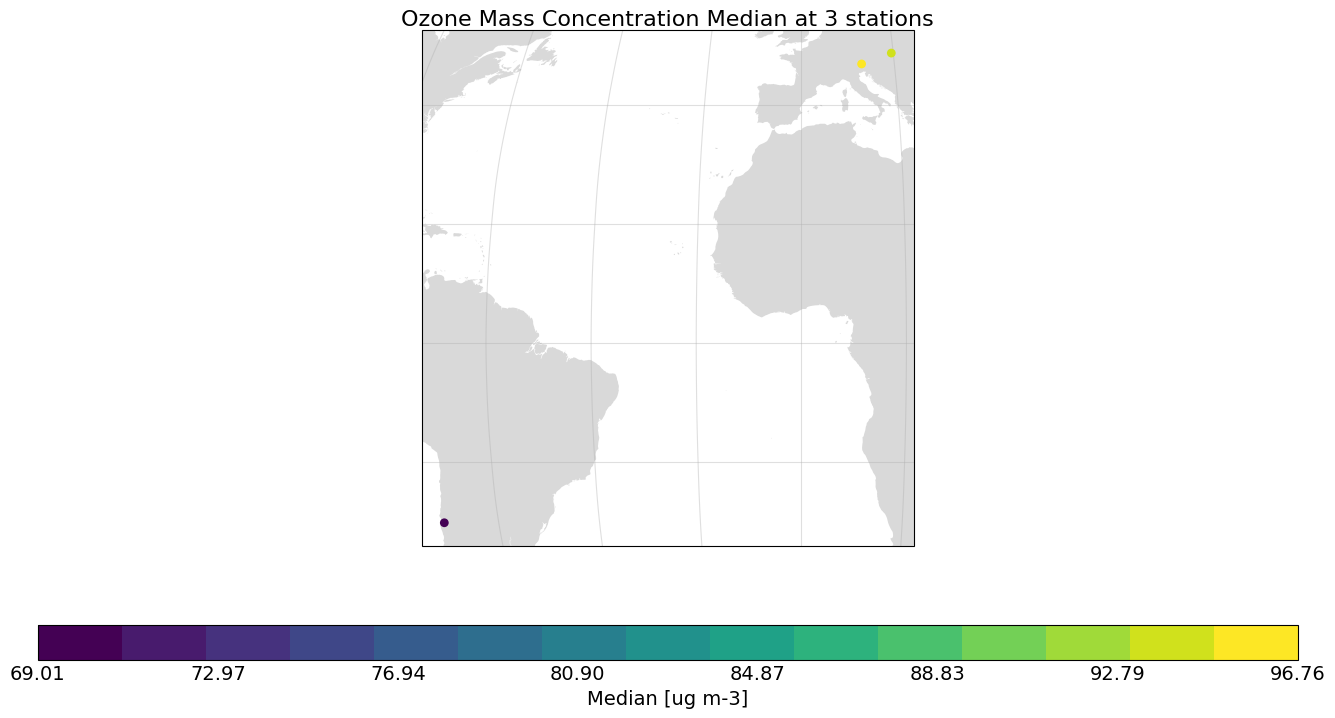

In [25]:
provi.plot('map-Median')

### By station reference

In [26]:
stations_data['actris_actris|sconco3_station_reference']

<xarray.DataArray 'actris_actris|sconco3_station_reference' (
                                                             station_actris_actris|sconco3: 3,
                                                             month: 12)> Size: 1kB
array([['AT0034G', 'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G',
        'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G'],
       ['CL0001R', 'CL0001R', 'CL0001R', 'CL0001R', 'CL0001R', 'CL0001R',
        'CL0001R', 'CL0001R', 'CL0001R', 'nan', 'CL0001R', 'CL0001R'],
       ['SK0002R', 'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R',
        'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R']],
      dtype='<U7')
Dimensions without coordinates: station_actris_actris|sconco3, month
Attributes:
    standard_name:  station reference
    long_name:      station reference identifier
    units:          unitless
    description:    reference ID for station.

In [29]:
provi.filter_station(['AT0034G'])
stations_data = provi.data(format='xr')
stations_data

Filtering data


<xarray.Dataset> Size: 116kB
Dimensions:                                                       (
                                                                   data_label: 1,
                                                                   station_actris_actris|sconco3: 1,
                                                                   time: 8784,
                                                                   month: 12)
Coordinates:
  * time                                                          (time) datetime64[ns] 70kB ...
Dimensions without coordinates: data_label, station_actris_actris|sconco3, month
Data variables: (12/29)
    data_labels                                                   (data_label) <U24 96B ...
    actris_actris|sconco3_data                                    (data_label, station_actris_actris|sconco3, time) float32 35kB ...
    actris_actris|sconco3_station_reference                       (station_actris_actris|sconco3, month) <U7 336B ...
    actris_actris|sconco3_longitude                               (station_actris_actris|sconco3, month) float64 96B ...
    actris_actris|sconco3_latitude                                (station_actris_actris|sconco3, month) float64 96B ...
    actris_actris|sconco3_station_name                            (station_actris_actris|sconco3, month) <U9 432B ...
    ...                                                            ...
    actris_actris|sconco3_contact_name                            (station_actris_actris|sconco3, month) <U12 576B ...
    actris_actris|sconco3_contact_institution                     (station_actris_actris|sconco3, month) <U4 192B ...
    actris_actris|sconco3_contact_email_address                   (station_actris_actris|sconco3, month) <U12 576B ...
    actris_actris|sconco3_data_licence                            (station_actris_actris|sconco3, month) <U3 144B ...
    actris_actris|sconco3_doi                                     (station_actris_actris|sconco3, month) <U4 192B ...
    actris_actris|sconco3_actris_national_facility                (station_actris_actris|sconco3, month) <U4 192B ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

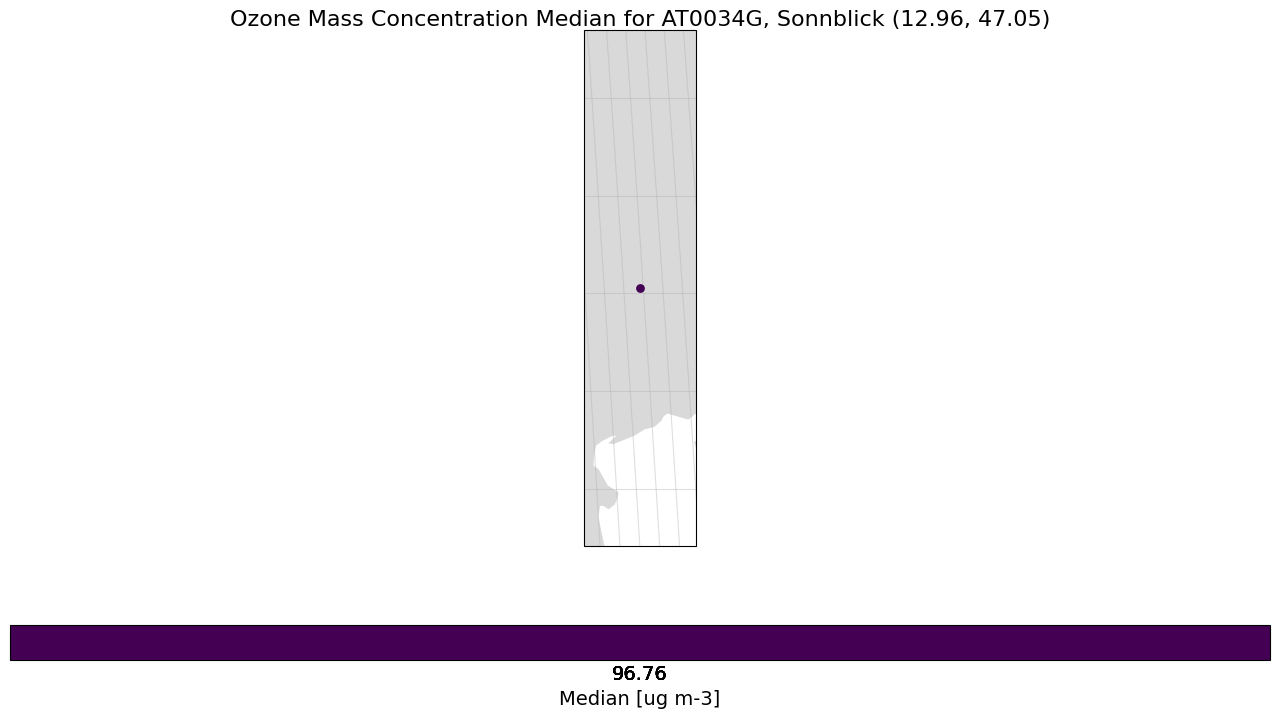

In [30]:
provi.plot('map-Median')